In [2]:
from google.colab import files
uploaded = files.upload()

Saving Reviews.csv to Reviews.csv


In [3]:
import os
print(os.listdir())

['.config', 'Reviews.csv', 'drive', 'sample_data']


In [4]:
# ── Install & Downloads ───────────────────────────────────────
!pip install vaderSentiment textblob wordcloud -q

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)

print("✅ All libraries have been loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00
✅ All libraries have been loaded.


In [5]:
# ============================================================
# TASK 4: Sentiment Analysis — Amazon Fine Food Reviews
# Methods : VADER → TextBlob → Logistic Regression + Random Forest
# Dataset : Reviews.csv (568,454 reviews)
# Output  : sentiment_results.csv + 7 charts
# ============================================================

import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# ── Visual style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Global constants ──────────────────────────────────────────
DATA_FILE   = "Reviews.csv"
OUTPUT_FILE = "sentiment_results.csv"
SAMPLE_SIZE = 10_000       # balanced — 2k per star rating
RANDOM_SEED = 42
PALETTE     = {
    "positive": "#2ecc71",
    "neutral":  "#f39c12",
    "negative": "#e74c3c",
}

print("✅ Setup complete.")

✅ Setup complete.


In [6]:
# ── Helper functions ──────────────────────────────────────────

def clean_text(text: str) -> str:
    """
    Strip HTML tags, URLs, special characters.
    Lowercase. Return empty string for non-string inputs.
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(r"http\S+|www\S+",        " ", text)   # URLs
    text = re.sub(r"<[^>]+>",               " ", text)   # HTML tags
    text = re.sub(r"[^a-zA-Z\s]",           " ", text)   # non-alpha
    text = re.sub(r"\s+",                   " ", text)   # whitespace
    return text.lower().strip()


def score_to_sentiment(score: int) -> str:
    """Map 1–5 star rating to sentiment label (ground truth for ML)."""
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    return "negative"


def vader_label(compound: float) -> str:
    """Map VADER compound score to sentiment label."""
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    return "neutral"


def textblob_label(polarity: float) -> str:
    """Map TextBlob polarity to sentiment label."""
    if polarity > 0.05:
        return "positive"
    elif polarity < -0.05:
        return "negative"
    return "neutral"


def save_chart(fig: plt.Figure, filename: str) -> None:
    """Save figure as high-quality PNG."""
    fig.savefig(filename, bbox_inches="tight",
                facecolor="white", dpi=150)
    print(f"  [✓] {filename}")

print("✅ Features are ready.")

✅ Features are ready.


In [7]:
# ── Load & Sample ─────────────────────────────────────────────
print("=" * 60)
print("  SECTION 1 — LOAD & CLEAN")
print("=" * 60)

df_raw = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
print(f"  Full dataset   : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")

# Keep only what we need
df = (
    df_raw[["Score", "Text", "Summary"]]
    .dropna(subset=["Text", "Score"])
    .copy()
)
df["Score"] = df["Score"].astype(int).clip(1, 5)

# Balanced stratified sample — equal per star rating
df = (
    df.groupby("Score", group_keys=False)
    .apply(lambda g: g.sample(
        min(len(g), SAMPLE_SIZE // 5),
        random_state=RANDOM_SEED
    ))
    .reset_index(drop=True)
)

# Text cleaning
df["clean_text"]    = df["Text"].apply(clean_text)
df["sentiment_gt"]  = df["Score"].apply(score_to_sentiment)

# Drop empty rows after cleaning
df = df[df["clean_text"].str.len() > 10].reset_index(drop=True)

print(f"  Sampled shape  : {df.shape[0]:,} rows")
print(f"  Star distribution:\n{df['Score'].value_counts().sort_index().to_string()}")
print(f"\n  Example clean  : {df['clean_text'].iloc[0][:90]}...")
print("\n✅ Data is ready.")

  SECTION 1 — LOAD & CLEAN
  Full dataset   : 568,454 rows × 10 cols
  Sampled shape  : 10,000 rows
  Star distribution:
Score
1    2000
2    2000
3    2000
4    2000
5    2000

  Example clean  : if you like the bitter taste of sweet low get this if you don t don t couldn t get through...

✅ Data is ready.


In [8]:
# ── VADER Scoring ─────────────────────────────────────────────
print("=" * 60)
print("  SECTION 2 — VADER SENTIMENT SCORING")
print("=" * 60)

analyzer   = SentimentIntensityAnalyzer()
vader_scores = df["clean_text"].apply(analyzer.polarity_scores)

df["vader_neg"]      = vader_scores.apply(lambda x: x["neg"])
df["vader_neu"]      = vader_scores.apply(lambda x: x["neu"])
df["vader_pos"]      = vader_scores.apply(lambda x: x["pos"])
df["vader_compound"] = vader_scores.apply(lambda x: x["compound"])
df["vader_label"]    = df["vader_compound"].apply(vader_label)

vader_counts = df["vader_label"].value_counts()
print(f"  VADER distribution:\n{vader_counts.to_string()}")

# ── TextBlob Scoring ──────────────────────────────────────────
print("\n" + "=" * 60)
print("  SECTION 3 — TEXTBLOB SENTIMENT SCORING")
print("=" * 60)

tb_scores            = df["clean_text"].apply(lambda t: TextBlob(t).sentiment)
df["tb_polarity"]    = tb_scores.apply(lambda s: s.polarity)
df["tb_subjectivity"]= tb_scores.apply(lambda s: s.subjectivity)
df["tb_label"]       = df["tb_polarity"].apply(textblob_label)

tb_counts  = df["tb_label"].value_counts()
agreement  = (df["vader_label"] == df["tb_label"]).mean()

print(f"  TextBlob distribution:\n{tb_counts.to_string()}")
print(f"\n  VADER ↔ TextBlob agreement : {agreement:.1%}")
print("  ⚠ Agreement ≠ accuracy — both are unsupervised.")
print("\n✅ Scoring is completed.")

  SECTION 2 — VADER SENTIMENT SCORING
  VADER distribution:
vader_label
positive    7886
negative    1772
neutral      342

  SECTION 3 — TEXTBLOB SENTIMENT SCORING
  TextBlob distribution:
tb_label
positive    7176
neutral     1504
negative    1320

  VADER ↔ TextBlob agreement : 74.5%
  ⚠ Agreement ≠ accuracy — both are unsupervised.

✅ Scoring is completed.


In [9]:
# ── ML Pipeline ───────────────────────────────────────────────
print("=" * 60)
print("  SECTION 4 — ML CLASSIFIER (LR + RF)")
print("=" * 60)

# Binary: positive vs negative (remove neutral for clarity)
ml_df = df[df["sentiment_gt"] != "neutral"].copy()
X     = ml_df["clean_text"]
y     = ml_df["sentiment_gt"]

print(f"  ML dataset     : {len(ml_df):,} reviews (pos + neg)")

# Split BEFORE fitting — no data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_SEED,
    stratify     = y
)
print(f"  Train          : {len(X_train):,}  |  Test : {len(X_test):,}")

# ── Model 1: Logistic Regression ─────────────────────────────
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 15_000,
        ngram_range  = (1, 2),
        stop_words   = "english",
        min_df       = 2,
        sublinear_tf = True,    # log scaling — better for text
    )),
    ("clf", LogisticRegression(
        C            = 1.0,
        max_iter     = 1_000,
        random_state = RANDOM_SEED,
        solver       = "lbfgs",
    )),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr  = lr_pipeline.predict(X_test)
acc_lr     = accuracy_score(y_test, y_pred_lr)

print(f"\n  ✅ Logistic Regression Accuracy : {acc_lr:.1%}")
print(classification_report(y_test, y_pred_lr))

# ── Model 2: Random Forest ────────────────────────────────────
rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features = 10_000,
        ngram_range  = (1, 2),
        stop_words   = "english",
        min_df       = 2,
        sublinear_tf = True,
    )),
    ("clf", RandomForestClassifier(
        n_estimators = 200,
        max_depth    = 20,
        random_state = RANDOM_SEED,
        n_jobs       = -1,
    )),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf  = rf_pipeline.predict(X_test)
acc_rf     = accuracy_score(y_test, y_pred_rf)

print(f"  ✅ Random Forest Accuracy       : {acc_rf:.1%}")
print(classification_report(y_test, y_pred_rf))

# Best model
best_model  = "Logistic Regression" if acc_lr >= acc_rf else "Random Forest"
best_acc    = max(acc_lr, acc_rf)
best_pred   = y_pred_lr if acc_lr >= acc_rf else y_pred_rf
print(f"\n  🏆 Best model : {best_model} ({best_acc:.1%})")
print("\n✅ ML is completed.")

  SECTION 4 — ML CLASSIFIER (LR + RF)
  ML dataset     : 8,000 reviews (pos + neg)
  Train          : 6,400  |  Test : 1,600

  ✅ Logistic Regression Accuracy : 83.8%
              precision    recall  f1-score   support

    negative       0.84      0.84      0.84       800
    positive       0.84      0.84      0.84       800

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600

  ✅ Random Forest Accuracy       : 78.6%
              precision    recall  f1-score   support

    negative       0.80      0.76      0.78       800
    positive       0.77      0.81      0.79       800

    accuracy                           0.79      1600
   macro avg       0.79      0.79      0.79      1600
weighted avg       0.79      0.79      0.79      1600


  🏆 Best model : Logistic Regression (83.8%)

✅ ML is completed.


  SECTION 5 — CHARTS
  [✓] sent1_vader_distribution.png


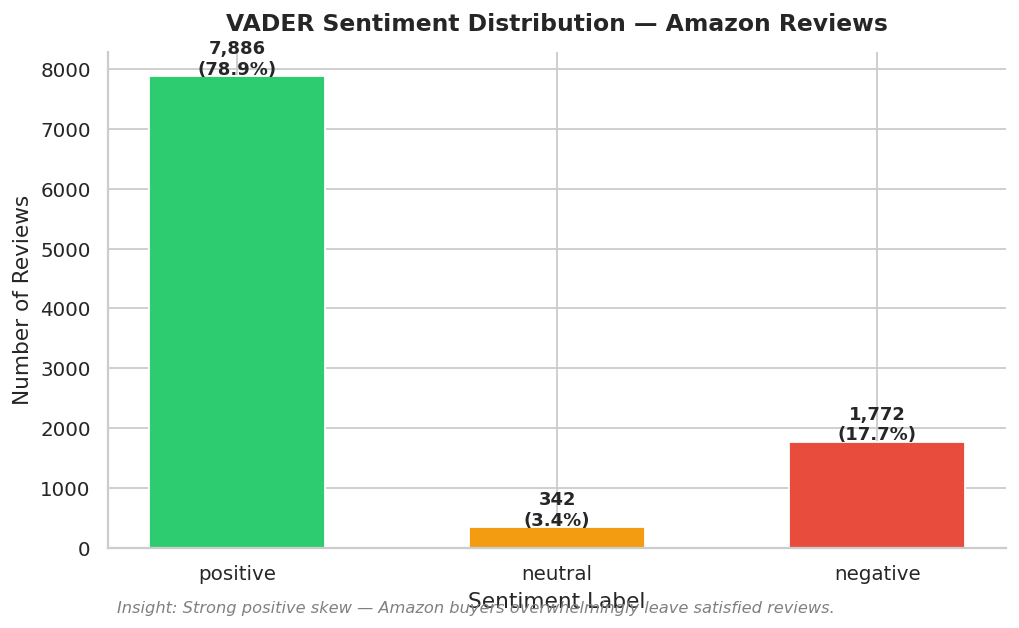

  [✓] sent2_vader_vs_textblob.png


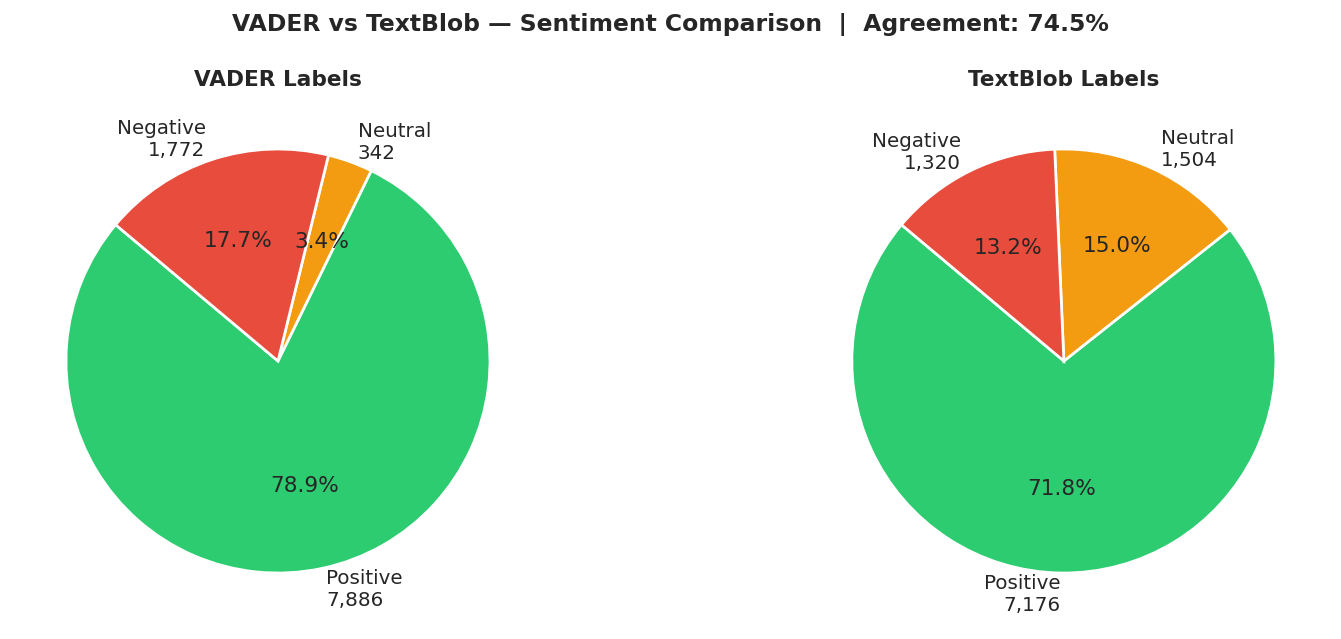

  [✓] sent3_compound_distribution.png


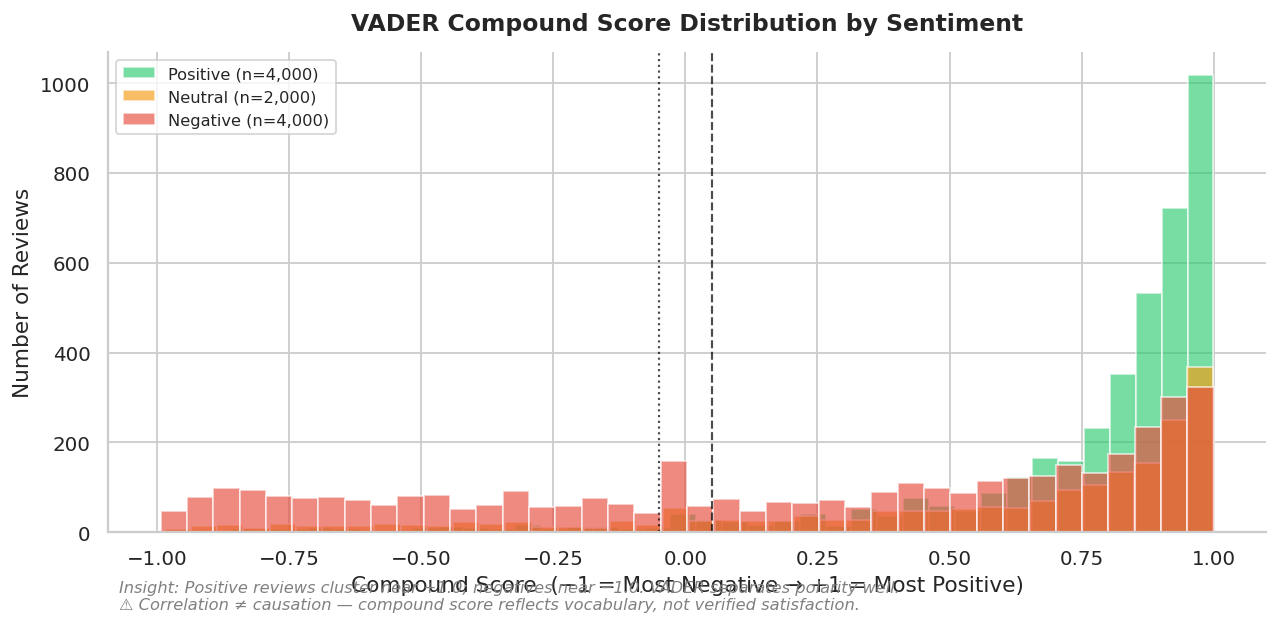

  [✓] sent4_confusion_matrix.png


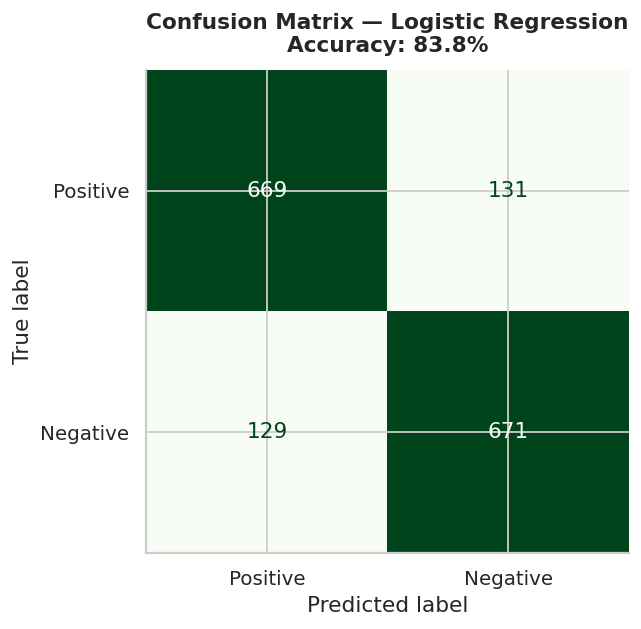

  [✓] sent5_polarity_subjectivity.png


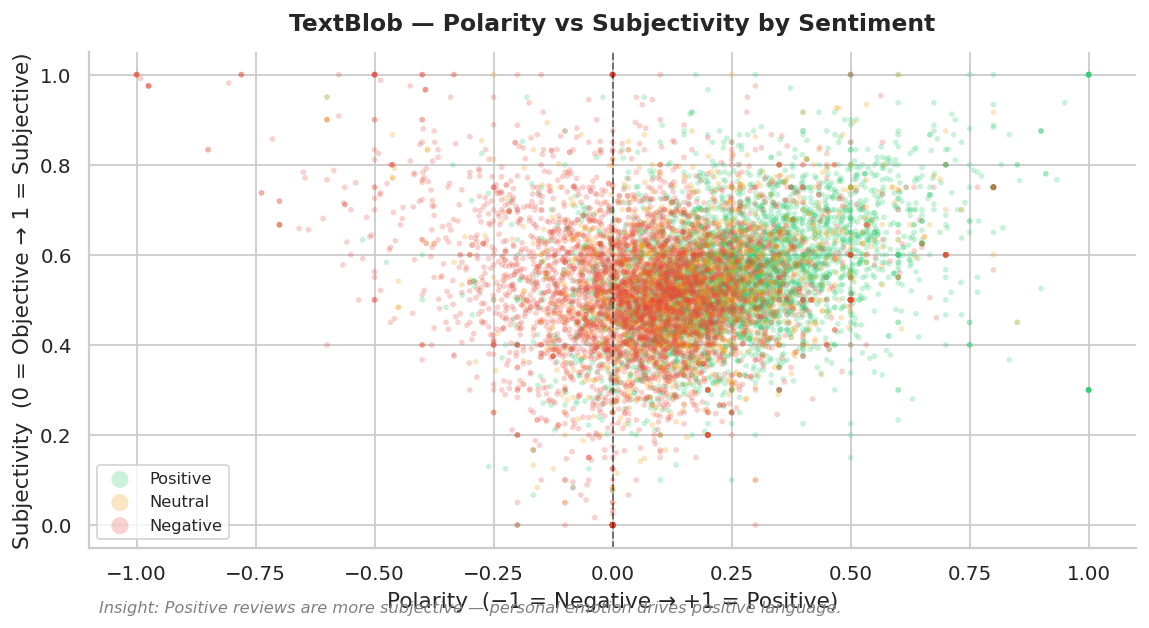

  [✓] sent6_wordcloud.png


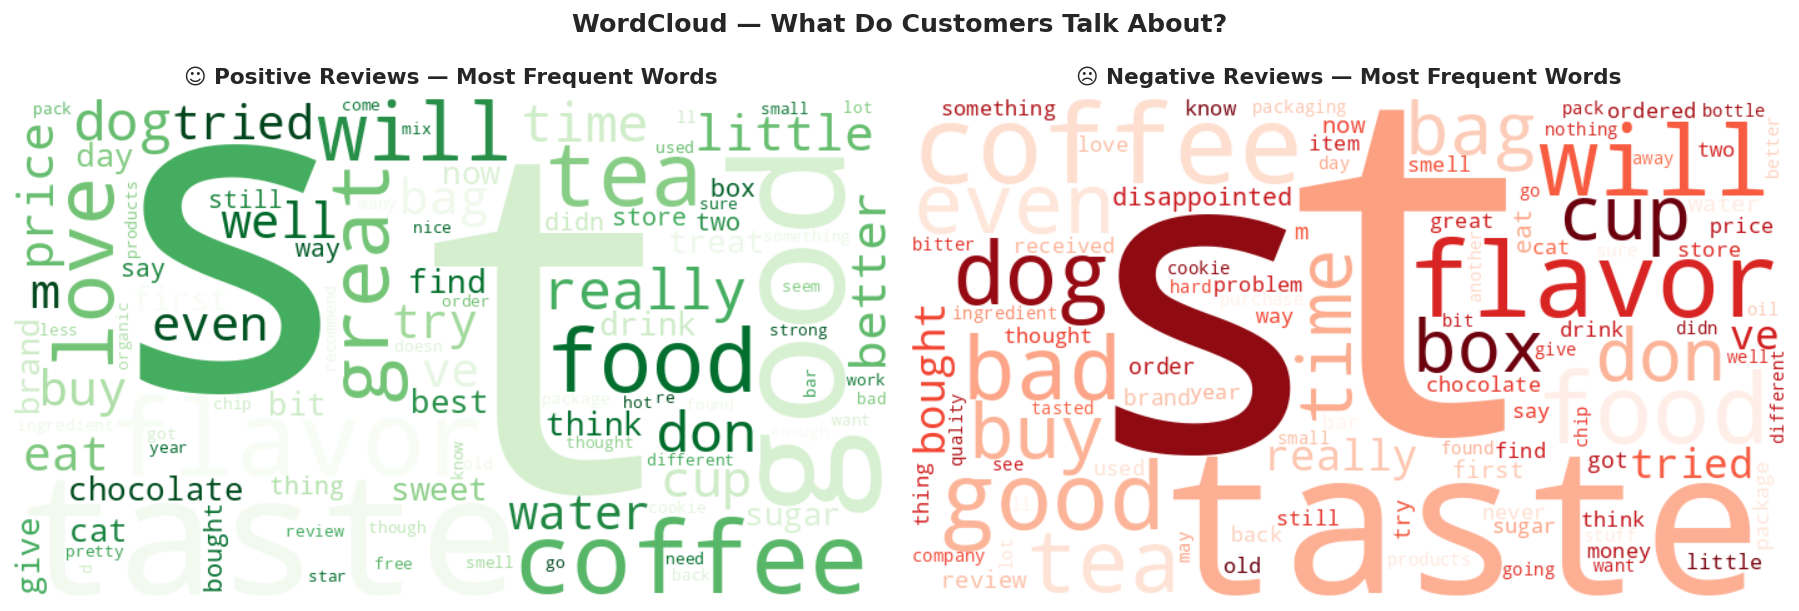

  [✓] sent7_model_comparison.png


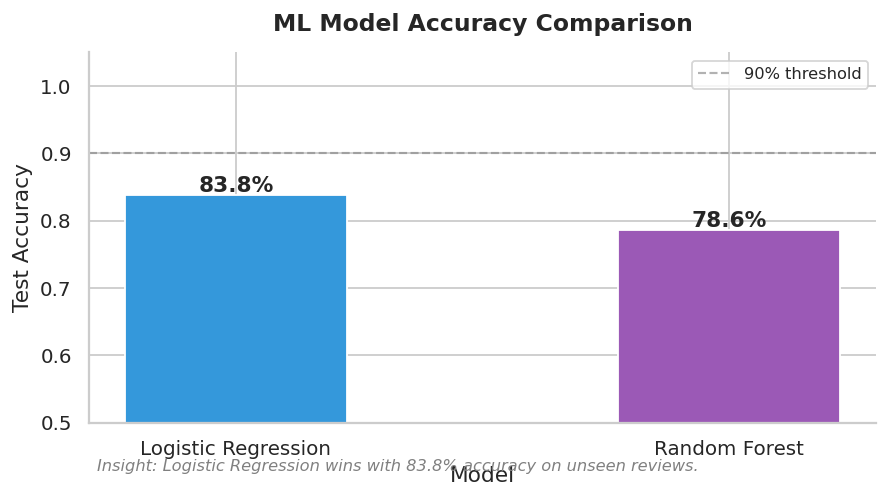


✅ ALL 7 charts are ready.


In [10]:
# ============================================================
# SECTION 5 — VISUALIZATIONS (7 charts)
# ============================================================
print("=" * 60)
print("  SECTION 5 — CHARTS")
print("=" * 60)

# ── Chart 1: VADER Distribution ──────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
vc         = df["vader_label"].value_counts().reindex(["positive","neutral","negative"])
bar_colors = [PALETTE[l] for l in vc.index]
bars       = ax1.bar(vc.index, vc.values, color=bar_colors,
                     edgecolor="white", width=0.55)
for bar, val in zip(bars, vc.values):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f"{val:,}\n({val/len(df):.1%})",
             ha="center", fontsize=10, fontweight="bold")
ax1.set_title("VADER Sentiment Distribution — Amazon Reviews",
              fontsize=13, fontweight="bold", pad=12)
ax1.set_xlabel("Sentiment Label")
ax1.set_ylabel("Number of Reviews")
ax1.set_ylim(0, vc.max() + 400)
ax1.annotate(
    "Insight: Strong positive skew — Amazon buyers overwhelmingly leave satisfied reviews.",
    xy=(0.01, -0.13), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)
plt.tight_layout()
save_chart(fig1, "sent1_vader_distribution.png")
plt.show()

# ── Chart 2: VADER vs TextBlob Pie ───────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, counts, title in zip(
    axes2,
    ["vader_label", "tb_label"],
    [vader_counts, tb_counts],
    ["VADER", "TextBlob"]
):
    ordered = counts.reindex(["positive", "neutral", "negative"]).dropna()
    ax.pie(
        ordered.values,
        labels    = [f"{l.capitalize()}\n{v:,}" for l, v in ordered.items()],
        autopct   = "%1.1f%%",
        colors    = [PALETTE[l] for l in ordered.index],
        startangle= 140,
        wedgeprops= dict(edgecolor="white", linewidth=1.5),
    )
    ax.set_title(f"{title} Labels", fontsize=12, fontweight="bold")
fig2.suptitle(
    f"VADER vs TextBlob — Sentiment Comparison  |  Agreement: {agreement:.1%}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
save_chart(fig2, "sent2_vader_vs_textblob.png")
plt.show()

# ── Chart 3: Compound Score Histogram ────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 5))
for label, color in PALETTE.items():
    subset = df[df["sentiment_gt"] == label]["vader_compound"]
    if len(subset):
        ax3.hist(subset, bins=40, alpha=0.65,
                 color=color, label=f"{label.capitalize()} (n={len(subset):,})",
                 edgecolor="white")
ax3.axvline( 0.05, color="black", linestyle="--", lw=1.2, alpha=0.7)
ax3.axvline(-0.05, color="black", linestyle=":",  lw=1.2, alpha=0.7)
ax3.set_title("VADER Compound Score Distribution by Sentiment",
              fontsize=13, fontweight="bold", pad=12)
ax3.set_xlabel("Compound Score  (−1 = Most Negative → +1 = Most Positive)")
ax3.set_ylabel("Number of Reviews")
ax3.legend(fontsize=9)
ax3.annotate(
    "Insight: Positive reviews cluster near +1.0; negatives near −1.0. VADER separates polarity well.\n"
    "⚠ Correlation ≠ causation — compound score reflects vocabulary, not verified satisfaction.",
    xy=(0.01, -0.16), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)
plt.tight_layout()
save_chart(fig3, "sent3_compound_distribution.png")
plt.show()

# ── Chart 4: Confusion Matrix ─────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(6, 5))
cm   = confusion_matrix(y_test, best_pred,
                        labels=["positive", "negative"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Positive", "Negative"])
disp.plot(ax=ax4, colorbar=False, cmap="Greens")
ax4.set_title(
    f"Confusion Matrix — {best_model}\nAccuracy: {best_acc:.1%}",
    fontsize=12, fontweight="bold", pad=10
)
plt.tight_layout()
save_chart(fig4, "sent4_confusion_matrix.png")
plt.show()

# ── Chart 5: Polarity vs Subjectivity Scatter ────────────────
fig5, ax5 = plt.subplots(figsize=(9, 5))
for label, color in PALETTE.items():
    subset = df[df["sentiment_gt"] == label]
    ax5.scatter(
        subset["tb_polarity"],
        subset["tb_subjectivity"],
        c         = color,
        alpha     = 0.25,
        s         = 10,
        label     = label.capitalize(),
        edgecolors= "none",
    )
ax5.axvline(0, color="black", linestyle="--", lw=1, alpha=0.5)
ax5.set_title("TextBlob — Polarity vs Subjectivity by Sentiment",
              fontsize=13, fontweight="bold", pad=12)
ax5.set_xlabel("Polarity  (−1 = Negative → +1 = Positive)")
ax5.set_ylabel("Subjectivity  (0 = Objective → 1 = Subjective)")
ax5.legend(fontsize=9, markerscale=3)
ax5.annotate(
    "Insight: Positive reviews are more subjective — personal emotion drives positive language.",
    xy=(0.01, -0.13), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)
plt.tight_layout()
save_chart(fig5, "sent5_polarity_subjectivity.png")
plt.show()

# ── Chart 6: WordCloud — Positive vs Negative ────────────────
stop_extra = {
    "br", "one", "get", "would", "also", "us", "use",
    "make", "made", "much", "like", "product", "amazon",
}

def make_wordcloud(texts: pd.Series, color: str, title: str, ax: plt.Axes) -> None:
    """Generate and display a WordCloud on the given axis."""
    combined = " ".join(texts.dropna())
    wc = WordCloud(
        width            = 700,
        height           = 400,
        background_color = "white",
        colormap         = "Greens" if color == "positive" else "Reds",
        stopwords        = set(WordCloud().stopwords) | stop_extra,
        max_words        = 100,
        collocations     = False,
    ).generate(combined)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)

fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5))
make_wordcloud(
    df[df["vader_label"] == "positive"]["clean_text"],
    "positive", "☺ Positive Reviews — Most Frequent Words", axes6[0]
)
make_wordcloud(
    df[df["vader_label"] == "negative"]["clean_text"],
    "negative", "☹ Negative Reviews — Most Frequent Words", axes6[1]
)
fig6.suptitle("WordCloud — What Do Customers Talk About?",
              fontsize=14, fontweight="bold")
plt.tight_layout()
save_chart(fig6, "sent6_wordcloud.png")
plt.show()

# ── Chart 7: Model Accuracy Comparison ───────────────────────
fig7, ax7 = plt.subplots(figsize=(7, 4))
models     = ["Logistic Regression", "Random Forest"]
accs       = [acc_lr, acc_rf]
bar_cols   = ["#3498db", "#9b59b6"]
bars7      = ax7.bar(models, accs, color=bar_cols,
                     edgecolor="white", width=0.45)
for bar, val in zip(bars7, accs):
    ax7.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.1%}", ha="center",
             fontsize=12, fontweight="bold")
ax7.set_ylim(0.5, 1.05)
ax7.set_title("ML Model Accuracy Comparison",
              fontsize=13, fontweight="bold", pad=12)
ax7.set_xlabel("Model")
ax7.set_ylabel("Test Accuracy")
ax7.axhline(0.9, color="gray", linestyle="--",
            lw=1.2, alpha=0.6, label="90% threshold")
ax7.legend(fontsize=9)
ax7.annotate(
    f"Insight: {best_model} wins with {best_acc:.1%} accuracy on unseen reviews.",
    xy=(0.01, -0.13), xycoords="axes fraction",
    fontsize=9, style="italic", color="gray"
)
plt.tight_layout()
save_chart(fig7, "sent7_model_comparison.png")
plt.show()

print("\n✅ ALL 7 charts are ready.")

In [11]:
# ── Save results ──────────────────────────────────────────────
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")

print("\n" + "=" * 60)
print("  TASK 4 COMPLETE — SENTIMENT ANALYSIS")
print("=" * 60)
print(f"  Dataset          : Amazon Fine Food Reviews")
print(f"  Sample           : {len(df):,} reviews (balanced)")
print(f"  VADER positive   : {vader_counts.get('positive',0):,} "
      f"({vader_counts.get('positive',0)/len(df):.1%})")
print(f"  VADER negative   : {vader_counts.get('negative',0):,} "
      f"({vader_counts.get('negative',0)/len(df):.1%})")
print(f"  VADER neutral    : {vader_counts.get('neutral',0):,} "
      f"({vader_counts.get('neutral',0)/len(df):.1%})")
print(f"  VADER↔TextBlob   : {agreement:.1%} agreement")
print(f"  Logistic Reg.    : {acc_lr:.1%}")
print(f"  Random Forest    : {acc_rf:.1%}")
print(f"  🏆 Best model    : {best_model} ({best_acc:.1%})")
print(f"  Output saved     : {OUTPUT_FILE}")
print()
print("  Charts:")
charts = [
    "sent1_vader_distribution.png  → VADER bar chart",
    "sent2_vader_vs_textblob.png   → Pie comparison",
    "sent3_compound_distribution.png → Compound histogram",
    "sent4_confusion_matrix.png    → Confusion matrix",
    "sent5_polarity_subjectivity.png → Scatter plot",
    "sent6_wordcloud.png           → WordCloud pos vs neg",
    "sent7_model_comparison.png    → Model accuracy bar",
]
for c in charts:
    print(f"  • {c}")
print()
print("  ⚠ Correlation ≠ causation — always.")


  TASK 4 COMPLETE — SENTIMENT ANALYSIS
  Dataset          : Amazon Fine Food Reviews
  Sample           : 10,000 reviews (balanced)
  VADER positive   : 7,886 (78.9%)
  VADER negative   : 1,772 (17.7%)
  VADER neutral    : 342 (3.4%)
  VADER↔TextBlob   : 74.5% agreement
  Logistic Reg.    : 83.8%
  Random Forest    : 78.6%
  🏆 Best model    : Logistic Regression (83.8%)
  Output saved     : sentiment_results.csv

  Charts:
  • sent1_vader_distribution.png  → VADER bar chart
  • sent2_vader_vs_textblob.png   → Pie comparison
  • sent3_compound_distribution.png → Compound histogram
  • sent4_confusion_matrix.png    → Confusion matrix
  • sent5_polarity_subjectivity.png → Scatter plot
  • sent6_wordcloud.png           → WordCloud pos vs neg
  • sent7_model_comparison.png    → Model accuracy bar

  ⚠ Correlation ≠ causation — always.
